
# Customer Credit Risk Analysis Project

## Project Overview
This notebook performs:
- Data Acquisition
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Missing Value Handling
- Outlier Detection & Treatment
- Feature Engineering
- Encoding
- Scaling
- Feature Transformation
- Final Dataset Preparation

Dataset Source:
- CSV
- JSON
- SQLite Database


In [50]:
import pandas as pd
import numpy as np
import sqlite3
import json
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
    MaxAbsScaler,
    PowerTransformer,
    FunctionTransformer,
    KBinsDiscretizer,
    Binarizer
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from scipy import stats

import warnings
warnings.filterwarnings('ignore')



# Part A: Conceptual Foundation

## What is Data Analysis?
Data analysis is the process of collecting, cleaning, transforming, and interpreting data to discover useful insights and support decision-making.

## How to Plan a Data Science Project?
1. Understand business problem
2. Collect data
3. Clean and preprocess data
4. Perform EDA
5. Build ML model
6. Evaluate model
7. Deploy solution

## What is Machine Learning Problem Framing?
Problem framing means identifying:
- Input features
- Target variable
- Type of problem (classification/regression)
- Evaluation metric

In this project:
- Target = `default_flag`
- Problem Type = Binary Classification

## What are Tensors?
A tensor is a multi-dimensional array.

- Scalar → 0D Tensor
- Vector → 1D Tensor
- Matrix → 2D Tensor
- Higher dimensions → nD Tensor





In [51]:
scalar = np.array(10)
vector = np.array([1,2,3])
matrix = np.array([[1,2],[3,4]])
tensor_3d = np.array([[[1,2],[3,4]], [[5,6],[7,8]]])

print("Scalar Shape:", scalar.shape)
print("Vector Shape:", vector.shape)
print("Matrix Shape:", matrix.shape)
print("3D Tensor Shape:", tensor_3d.shape)


Scalar Shape: ()
Vector Shape: (3,)
Matrix Shape: (2, 2)
3D Tensor Shape: (2, 2, 2)


# Part B: Data Acquisition

* Load CSV File

In [ ]:
df_csv = pd.read_csv('customer_credit_risk_dataset.csv')
df_csv.head()


,customer_id,age,gender,region,education_level,employment_type,annual_income,loan_amount,loan_purpose,credit_score,repayment_history,transaction_count,spending_ratio,join_date,default_flag
0,1,60.0,Other,North,Primary,Unemployed,724178.54,279260.35,Education,731.0,1,107,38.37,2018-03-14,0
1,2,45.0,Male,South,Secondary,Unemployed,980757.46,212868.28,Home,637.0,1,41,10.60,2021-04-08,0
2,3,23.0,Other,North,Post-Graduate,Salaried,804111.27,71418.60,Home,645.0,2,70,42.51,2024-02-13,0
3,4,29.0,Male,South,Secondary,Unemployed,414398.29,362551.67,Other,746.0,1,108,92.08,2017-05-26,1
4,5,22.0,Male,South,Post-Graduate,Salaried,794798.16,134835.34,Business,770.0,1,69,66.31,2021-10-10,0


# Load JSON File

In [ ]:
with open('customer_metadata.json', 'r') as f:
    metadata = json.load(f)

metadata


{'dataset_name': 'Customer Credit Risk Dataset',
 'records': 1000,
 'columns': ['customer_id',
  'age',
  'gender',
  'region',
  'education_level',
  'employment_type',
  'annual_income',
  'loan_amount',
  'loan_purpose',
  'credit_score',
  'repayment_history',
  'transaction_count',
  'spending_ratio',
  'join_date',
  'default_flag'],
 'target_variable': 'default_flag',
 'description': 'Synthetic fintech dataset for EDA, preprocessing, feature engineering, and ML.'}

# Load SQLite Database

In [89]:
df = pd.read_csv('customer_credit_risk_dataset.csv')

conn = sqlite3.connect('customer_credit_risk.db')

df.to_sql(
    'customer_credit_data',
    conn,
    if_exists='replace',
    index=False
)
print(df.head())
conn.close()

print("Database recreated successfully.")


   customer_id   age gender region education_level employment_type  \
0            1  60.0  Other  North         Primary      Unemployed   
1            2  45.0   Male  South       Secondary      Unemployed   
2            3  23.0  Other  North   Post-Graduate        Salaried   
3            4  29.0   Male  South       Secondary      Unemployed   
4            5  22.0   Male  South   Post-Graduate        Salaried   

   annual_income  loan_amount loan_purpose  credit_score  repayment_history  \
0      724178.54    279260.35    Education         731.0                  1   
1      980757.46    212868.28         Home         637.0                  1   
2      804111.27     71418.60         Home         645.0                  2   
3      414398.29    362551.67        Other         746.0                  1   
4      794798.16    134835.34     Business         770.0                  1   

   transaction_count  spending_ratio   join_date  default_flag  
0                107           38.37  2

# Part C: Data Understanding & Cleaning
* Dataset Information

In [ ]:
df = df_csv.copy()

print(df.info())

df.describe(include='all')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        1000 non-null   int64  
 1   age                950 non-null    float64
 2   gender             1000 non-null   object 
 3   region             1000 non-null   object 
 4   education_level    1000 non-null   object 
 5   employment_type    950 non-null    object 
 6   annual_income      950 non-null    float64
 7   loan_amount        1000 non-null   float64
 8   loan_purpose       1000 non-null   object 
 9   credit_score       950 non-null    float64
 10  repayment_history  1000 non-null   int64  
 11  transaction_count  1000 non-null   int64  
 12  spending_ratio     1000 non-null   float64
 13  join_date          1000 non-null   object 
 14  default_flag       1000 non-null   int64  
dtypes: float64(5), int64(4), object(6)
memory usage: 117.3+ KB
None


,customer_id,age,gender,region,education_level,employment_type,annual_income,loan_amount,loan_purpose,credit_score,repayment_history,transaction_count,spending_ratio,join_date,default_flag
count,1000.000000,950.000000,1000,1000,1000,950,9.500000e+02,1.000000e+03,1000,950.000000,1000.000000,1000.000000,1000.000000,1000,1000.000000
unique,NaN,NaN,3,4,4,3,NaN,NaN,5,NaN,NaN,NaN,NaN,876,NaN
top,NaN,NaN,Male,West,Post-Graduate,Self-Employed,NaN,NaN,Home,NaN,NaN,NaN,NaN,2020-11-10,NaN
freq,NaN,NaN,344,267,263,318,NaN,NaN,212,NaN,NaN,NaN,NaN,3,NaN
mean,500.500000,42.895789,NaN,NaN,NaN,NaN,6.148584e+05,3.075894e+05,NaN,680.946316,1.959000,157.354000,52.720740,NaN,0.383000
std,288.819436,12.557085,NaN,NaN,NaN,NaN,3.568430e+05,1.762668e+05,NaN,79.049479,1.397595,78.700015,24.411181,NaN,0.486362
min,1.000000,21.000000,NaN,NaN,NaN,NaN,8.000000e+04,2.000000e+04,NaN,383.000000,0.000000,20.000000,10.140000,NaN,0.000000
25%,250.750000,33.000000,NaN,NaN,NaN,NaN,4.372364e+05,1.998367e+05,NaN,628.250000,1.000000,89.750000,32.305000,NaN,0.000000
50%,500.500000,43.000000,NaN,NaN,NaN,NaN,5.937442e+05,2.932331e+05,NaN,683.000000,2.000000,157.000000,52.760000,NaN,0.000000
75%,750.250000,54.000000,NaN,NaN,NaN,NaN,7.675664e+05,4.033968e+05,NaN,735.000000,3.000000,227.250000,74.910000,NaN,1.000000


# Missing Values

In [ ]:
df.isnull().sum()


customer_id           0
age                  50
gender                0
region                0
education_level       0
employment_type      50
annual_income        50
loan_amount           0
loan_purpose          0
credit_score         50
repayment_history     0
transaction_count     0
spending_ratio        0
join_date             0
default_flag          0
dtype: int64

## Simple Imputation

* Numerical Imputation


In [90]:

num_cols = ['age', 'annual_income', 'credit_score']

num_imputer = SimpleImputer(strategy='median')

df[num_cols] = num_imputer.fit_transform(df[num_cols])
print(df[num_cols].isnull().sum())


age              0
annual_income    0
credit_score     0
dtype: int64


# Categorical Imputation

In [91]:
cat_cols = ['employment_type']

cat_imputer = SimpleImputer(strategy='most_frequent')

df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])
print(df[cat_cols].isnull().sum())

employment_type    0
dtype: int64


# Most Frequent Imputation Example

In [92]:

gender_imputer = SimpleImputer(strategy='most_frequent')

df[['gender']] = gender_imputer.fit_transform(df[['gender']])
print(df['gender'].isnull().sum())

0


# Missing Indicator + Random Sample Imputation

In [93]:

df['income_missing'] = df['annual_income'].isnull().astype(int)

random_sample = df['annual_income'].dropna().sample(
    df['annual_income'].isnull().sum(),
    random_state=42,
    replace=True
)

random_sample.index = df[df['annual_income'].isnull()].index

df.loc[df['annual_income'].isnull(), 'annual_income'] = random_sample

print(df['annual_income'].isnull().sum())

0


# KNN Imputer

In [95]:
knn_cols = ['annual_income', 'loan_amount', 'credit_score']

knn_imputer = KNNImputer(n_neighbors=5)

df[knn_cols] = knn_imputer.fit_transform(df[knn_cols])

print(df[knn_cols].isnull().sum())

annual_income    0
loan_amount      0
credit_score     0
dtype: int64


# MICE Imputer

In [97]:
mice_imputer = IterativeImputer(random_state=42)

df[knn_cols] = mice_imputer.fit_transform(df[knn_cols])

print(df[knn_cols].isnull().sum())


annual_income    0
loan_amount      0
credit_score     0
dtype: int64


# Part D: Outlier Handling

# Boxplot

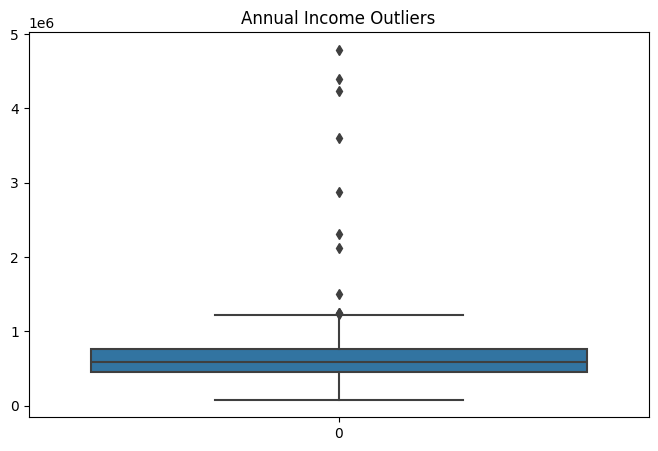

In [64]:

plt.figure(figsize=(8,5))
sns.boxplot(df['annual_income'])
plt.title('Annual Income Outliers')
plt.show()


In [65]:

# Z-Score Method

z_scores = np.abs(stats.zscore(df[['annual_income', 'loan_amount']]))

outliers_z = (z_scores > 3).sum()

print(outliers_z)


annual_income    7
loan_amount      7
dtype: int64


In [66]:

# IQR Method

Q1 = df['annual_income'].quantile(0.25)
Q3 = df['annual_income'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_iqr = df[(df['annual_income'] >= lower) & (df['annual_income'] <= upper)]

print("Original Shape:", df.shape)
print("After IQR:", df_iqr.shape)


Original Shape: (1000, 16)
After IQR: (989, 16)


In [67]:

# Winsorization

lower_limit = df['annual_income'].quantile(0.01)
upper_limit = df['annual_income'].quantile(0.99)

df['annual_income'] = np.where(
    df['annual_income'] > upper_limit,
    upper_limit,
    np.where(
        df['annual_income'] < lower_limit,
        lower_limit,
        df['annual_income']
    )
)


# Part E: Feature Engineering

In [98]:

# Date Feature Extraction

df['join_date'] = pd.to_datetime(df['join_date'])

df['join_year'] = df['join_date'].dt.year
df['join_month'] = df['join_date'].dt.month
df['join_weekday'] = df['join_date'].dt.weekday

print(df[['join_year', 'join_month', 'join_weekday']].head())

   join_year  join_month  join_weekday
0       2018           3             2
1       2021           4             3
2       2024           2             1
3       2017           5             4
4       2021          10             6


In [99]:

# Debt-to-Income Ratio

df['debt_to_income_ratio'] = df['loan_amount'] / df['annual_income']

print(df['debt_to_income_ratio'].head())

0    0.385624
1    0.217045
2    0.088817
3    0.874887
4    0.169647
Name: debt_to_income_ratio, dtype: float64


In [100]:

# Average Monthly Transactions

df['avg_monthly_transactions'] = df['transaction_count'] / 6
print(df['avg_monthly_transactions'].head())


0    17.833333
1     6.833333
2    11.666667
3    18.000000
4    11.500000
Name: avg_monthly_transactions, dtype: float64


# Encoding

In [101]:

# Ordinal Encoding

ordinal_encoder = OrdinalEncoder(
    categories=[['Primary', 'Secondary', 'Graduate', 'Post-Graduate']]
)

df[['education_level']] = ordinal_encoder.fit_transform(df[['education_level']])

print(df['education_level'].head())

0    0.0
1    1.0
2    3.0
3    1.0
4    3.0
Name: education_level, dtype: float64


In [102]:
# Label Encoding

label_encoder = LabelEncoder()

df['gender'] = label_encoder.fit_transform(df['gender'])

print(df['gender'].head())

0    2
1    1
2    2
3    1
4    1
Name: gender, dtype: int32


In [73]:

# One-Hot Encoding

df = pd.get_dummies(
    df,
    columns=['region', 'loan_purpose'],
    drop_first=True
)

df.head()


,customer_id,age,gender,education_level,employment_type,annual_income,loan_amount,credit_score,repayment_history,transaction_count,...,join_weekday,debt_to_income_ratio,avg_monthly_transactions,region_North,region_South,region_West,loan_purpose_Car,loan_purpose_Education,loan_purpose_Home,loan_purpose_Other
0,1,60.0,2,0.0,Unemployed,724178.54,279260.35,731.0,1,107,...,2,0.385624,17.833333,True,False,False,False,True,False,False
1,2,45.0,1,1.0,Unemployed,980757.46,212868.28,637.0,1,41,...,3,0.217045,6.833333,False,True,False,False,False,True,False
2,3,23.0,2,3.0,Salaried,804111.27,71418.60,645.0,2,70,...,1,0.088817,11.666667,True,False,False,False,False,True,False
3,4,29.0,1,1.0,Unemployed,414398.29,362551.67,746.0,1,108,...,4,0.874887,18.000000,False,True,False,False,False,False,True
4,5,22.0,1,3.0,Salaried,794798.16,134835.34,770.0,1,69,...,6,0.169647,11.500000,False,True,False,False,False,False,False


# Numerical Encoding

In [103]:

# Binning

kbins = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile')

df['income_bins'] = kbins.fit_transform(df[['annual_income']])

print(df['income_bins'].head())


0    3.0
1    4.0
2    4.0
3    1.0
4    4.0
Name: income_bins, dtype: float64


In [104]:

# Binarization

binarizer = Binarizer(threshold=700)

df['credit_score_binary'] = binarizer.fit_transform(df[['credit_score']])

print(df['credit_score_binary'].head())


0    1.0
1    0.0
2    0.0
3    1.0
4    1.0
Name: credit_score_binary, dtype: float64


In [105]:

# Quantile Binning

df['income_quantile_bin'] = pd.qcut(df['annual_income'], q=4, labels=False)

print(df['income_quantile_bin'].head())


0    2
1    3
2    3
3    0
4    3
Name: income_quantile_bin, dtype: int64


# Part F: Feature Scaling

In [77]:

# Scaling

scale_cols = ['annual_income', 'loan_amount', 'spending_ratio']

standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()
robust_scaler = RobustScaler()
maxabs_scaler = MaxAbsScaler()

df_standard = standard_scaler.fit_transform(df[scale_cols])
df_minmax = minmax_scaler.fit_transform(df[scale_cols])
df_robust = robust_scaler.fit_transform(df[scale_cols])
df_maxabs = maxabs_scaler.fit_transform(df[scale_cols])

print("Scaling Completed")


Scaling Completed


# Part G: Feature Transformation

In [106]:

# Log Transformation

df['log_spending_ratio'] = np.log1p(df['spending_ratio'])

print(df['log_spending_ratio'].head())

0    3.673004
1    2.451005
2    3.772991
3    4.533459
4    4.209309
Name: log_spending_ratio, dtype: float64


In [107]:

# Square Root Transformation

df['sqrt_spending_ratio'] = np.sqrt(df['spending_ratio'])

print(df['sqrt_spending_ratio'].head())

0    6.194352
1    3.255764
2    6.519969
3    9.595832
4    8.143095
Name: sqrt_spending_ratio, dtype: float64


In [108]:

# Box-Cox Transformation

positive_income = df['annual_income'] + 1

boxcox_data, _ = stats.boxcox(positive_income)

df['boxcox_income'] = boxcox_data

print(df['boxcox_income'].head())


0    320.713396
1    357.022001
2    332.813770
3    263.190378
4    331.445347
Name: boxcox_income, dtype: float64


In [109]:

# Yeo-Johnson Transformation

pt = PowerTransformer(method='yeo-johnson')

df['yeojohnson_loan'] = pt.fit_transform(df[['loan_amount']])

print(df['yeojohnson_loan'].head())


0   -0.032241
1   -0.451307
2   -1.626707
3    0.434159
4   -1.029343
Name: yeojohnson_loan, dtype: float64


# Column Transformer

In [110]:

# Column Transformer Example

numeric_features = ['annual_income', 'loan_amount', 'credit_score']
categorical_features = ['employment_type']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print(preprocessor)
print("Column Transformer Created")


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['annual_income', 'loan_amount',
                                  'credit_score']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['employment_type'])])
Column Transformer Created


# Final Dataset

In [111]:
# Final Dataset Shape

print(df.shape)

df.head()


(1000, 28)


,customer_id,age,gender,region,education_level,employment_type,annual_income,loan_amount,loan_purpose,credit_score,...,join_weekday,debt_to_income_ratio,avg_monthly_transactions,income_bins,credit_score_binary,income_quantile_bin,log_spending_ratio,sqrt_spending_ratio,boxcox_income,yeojohnson_loan
0,1,60.0,2,North,0.0,Unemployed,724178.54,279260.35,Education,731.0,...,2,0.385624,17.833333,3.0,1.0,2,3.673004,6.194352,320.713396,-0.032241
1,2,45.0,1,South,1.0,Unemployed,980757.46,212868.28,Home,637.0,...,3,0.217045,6.833333,4.0,0.0,3,2.451005,3.255764,357.022001,-0.451307
2,3,23.0,2,North,3.0,Salaried,804111.27,71418.60,Home,645.0,...,1,0.088817,11.666667,4.0,0.0,3,3.772991,6.519969,332.813770,-1.626707
3,4,29.0,1,South,1.0,Unemployed,414398.29,362551.67,Other,746.0,...,4,0.874887,18.000000,1.0,1.0,0,4.533459,9.595832,263.190378,0.434159
4,5,22.0,1,South,3.0,Salaried,794798.16,134835.34,Business,770.0,...,6,0.169647,11.500000,4.0,1.0,3,4.209309,8.143095,331.445347,-1.029343


In [112]:
# Save Final Processed Dataset

df.to_csv('final_cleaned_credit_dataset.csv', index=False)

print("Final dataset saved successfully.")


Final dataset saved successfully.



# Final Report Summary

## Missing Value Handling
- Simple Imputer
- KNN Imputer
- MICE Imputer
- Random Sample Imputation

## Outlier Handling
- Z-score
- IQR
- Winsorization

## Encoding
- Ordinal Encoding
- Label Encoding
- One-Hot Encoding

## Scaling
- StandardScaler
- MinMaxScaler
- RobustScaler
- MaxAbsScaler

## Feature Engineering
- Debt-to-Income Ratio
- Monthly Transactions
- Date Features

## Transformations
- Log
- Square Root
- Box-Cox
- Yeo-Johnson

This dataset is now ready for Machine Learning.
